In [8]:
import pandas as pd
import os

In [9]:
# List all CSV files in the pbp folder
pbp_folder = 'pbp'
csv_files = [f for f in os.listdir(pbp_folder) if f.endswith('.csv')]

# Sort files by year (assuming filename format pbpYYYY.csv)
csv_files.sort()

# Read and concatenate all CSV files
dfs = []
for file in csv_files:
    file_path = os.path.join(pbp_folder, file)
    df = pd.read_csv(file_path)
    dfs.append(df)

# Concatenate all dataframes
pbp_data = pd.concat(dfs, ignore_index=True)

# Display the shape of the combined dataframe
print(f"Combined PBP data shape: {pbp_data.shape}")
pbp_data.head()


Combined PBP data shape: (3998997, 16)


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
0,29600001,1,PT12M00.00S,0.0,0.0,NaN,0,NaN,period,start,NaN,0,0,0,Start of 1st Period (11:15 PM EST),1997
1,29600001,1,PT12M00.00S,0.0,0.0,BOS,442,P. Ellison,Jump Ball,NaN,NaN,0,0,0,Jump Ball Ellison vs. Longley: Tip to Harper,1997
2,29600001,1,PT11M39.00S,0.0,2.0,CHI,23,D. Rodman,Made Shot,Layup Shot,Made,0,0,0,Rodman Layup (2 PTS) (Longley 1 AST),1997
3,29600001,1,PT11M39.00S,0.0,0.0,BOS,442,P. Ellison,Foul,Shooting,NaN,0,0,0,Ellison S.FOUL (P1.T1),1997
4,29600001,1,PT11M39.00S,0.0,3.0,CHI,23,D. Rodman,Free Throw,Free Throw 1 of 1,NaN,0,0,0,Rodman Free Throw 1 of 1 (3 PTS),1997


In [17]:
pbp_data = pbp_data[pbp_data["type"].isin(["Made Shot", "Missed Shot"])]
pbp_data = pbp_data[pbp_data["player"] == "S. Curry"]

In [18]:
pbp_data.head()

,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist


In [12]:
pbp_data = pbp_data[pbp_data["season"] == 2016]

pbp_data.drop(columns=["desc", "season"], inplace=True)
pbp_data.head()

,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist


In [13]:
# pbp_data.to_csv("curry_shots.csv", index=False)


In [14]:
# curry_shots = pd.read_csv("curry_shots.csv")
pbp_data["clock"] = pd.to_timedelta(pbp_data["clock"])
quarter_length = pd.Timedelta(minutes=12)
pbp_data["clock"] = quarter_length - pbp_data["clock"]
curry_shots = pbp_data.sort_values(["period", "clock"], ascending=True)
curry_shots.head()


curry_shots["isMade"] = curry_shots["type"] == "Made Shot"
curry_shots["cumulativeMade"] = curry_shots["isMade"].cumsum()
curry_shots["cumulativeMissed"] = (~curry_shots["isMade"]).cumsum()
curry_shots["percentage"] = curry_shots["cumulativeMade"] / (curry_shots["cumulativeMade"] + curry_shots["cumulativeMissed"])
curry_shots["elapsed_time"] = (curry_shots["period"] - 1) * pd.Timedelta(minutes=12) + curry_shots["clock"]
curry_shots["consecutive_shots"] = 0
consecutive_makes = 0

for row in curry_shots.itertuples():
    if row.isMade:
        consecutive_makes += 1
    else:
        consecutive_makes = 0
    curry_shots.at[row.Index, "consecutive_shots"] = consecutive_makes


    
shots_after_two = curry_shots[curry_shots["consecutive_shots"].shift(1) == 2]
curry_shots["percentage"] = curry_shots["cumulativeMade"] / (curry_shots["cumulativeMade"] + curry_shots["cumulativeMissed"])
fg_after_two = shots_after_two["isMade"].mean()
overall_fg = curry_shots["isMade"].mean()
shots_after_two.head()



,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,isMade,cumulativeMade,cumulativeMissed,percentage,elapsed_time,consecutive_shots


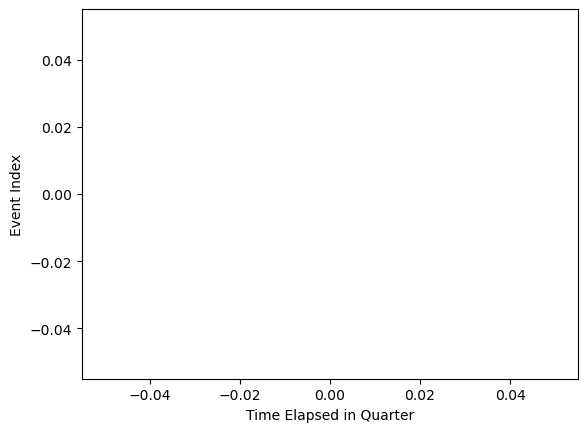

In [15]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf


plt.plot(curry_shots["elapsed_time"],curry_shots["percentage"] )
plt.xlabel("Time Elapsed in Quarter")
plt.ylabel("Event Index")
plt.show()

C:\Users\lilyh\anaconda3\New folder\Lib\site-packages\statsmodels\tsa\stattools.py:470: RuntimeWarning: Mean of empty slice.
  xo = x - x.mean()
C:\Users\lilyh\anaconda3\New folder\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: negative dimensions are not allowed

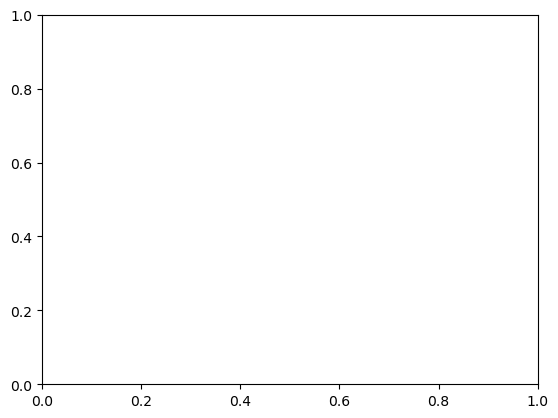

In [16]:
plot_acf(curry_shots["isMade"], lags=20)
plt.xlabel("Lag (Shots)")
plt.ylabel("Autocorrelation")
plt.title("ACF of Curry Shot Results - Game 21500003")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

labels = ["Overall FG%", "FG% After 2 Makes"]
values = [overall_fg, fg_after_two]

plt.bar(labels, values)
plt.ylim(0,1)

plt.ylabel("Field Goal Percentage")
plt.title("Steph Curry FG% After 2 Consecutive Makes")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center')

plt.show()

In [ ]:
# curry_shots = pd.read_csv("curry_shots.csv")

pbp_data["clock"] = pd.to_timedelta(pbp_data["clock"])
quarter_length = pd.Timedelta(minutes=12)
pbp_data["clock"] = quarter_length - pbp_data["clock"]

pbp_data = pbp_data.sort_values(["gameid", "period", "clock"])
pbp_data["isMade"] = pbp_data["type"] == "Made Shot"
pbp_data["consecutive_shots"] = 0

for game, df_game in pbp_data.groupby("gameid"):

    streak = 0

    for row in df_game.itertuples():
        if row.isMade:
            streak += 1
        else:
            streak = 0

        pbp_data.at[row.Index, "consecutive_shots"] = streak
        

shots_after_two = pbp_data[pbp_data["consecutive_shots"].shift(1) == 1]
shots_after_two = pbp_data[
    (pbp_data["consecutive_shots"].shift(1) == 1) &
    (pbp_data["gameid"] == pbp_data["gameid"].shift(1))
]
fg_after_two = shots_after_two["isMade"].mean()
overall_fg = pbp_data["isMade"].mean()

print("FG% after 4 makes:", fg_after_two)
print("Overall FG%:", overall_fg)
print("Attempts after 4 makes:", len(shots_after_two))

In [ ]:
import matplotlib.pyplot as plt

labels = ["Overall FG%", "FG% After 4 Makes"]
values = [overall_fg, fg_after_two]

plt.bar(labels, values)
plt.ylim(0,1)
plt.ylabel("Field Goal %")
plt.title("Steph Curry Hot Hand (Season)")

for i,v in enumerate(values):
    plt.text(i, v+0.02, f"{v*100:.1f}%", ha="center")

plt.show()